**BANK CUSTOMER CHURN PREDICTION**
###### - ANANYA PATANKAR


---



In [1]:
#import required libraries
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [2]:
#load the dataset
df = pd.read_csv('bank churn dataset.csv')

**UNDERSTANDING THE DATA :**

In [3]:
#first 5 rows
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


The target variable here is Exited.
It is a binary classification variable which indicates whether a customer has churned (1) or not (0). Thus it is a binary classification problem.


The dataset includes numerical (eg. Age, Balance) as well as categorical features (eg. Geography, Gender). Categorial features will require encoding before applying machine learning models.

In [4]:
#number of rows and columns
df.shape

(10000, 14)

The dataset contains 10000 rows and 14 columns, making it a reasonably sized dataset for training machine learning models.

In [5]:
#list of columns
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [6]:
#data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [7]:
#check for null values
df.isna().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [8]:
#check for duplicates
df.duplicated().sum()

np.int64(0)

The dataset does not contain any null values and duplicates, showing good data quality. This also helps simplify the data preprocessing stage.

In [9]:
#statistical summary
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [10]:
#check for class imbalance
display(df['Exited'].value_counts())
display(df['Exited'].value_counts(normalize = True))

,count
Exited,
0,7963
1,2037


,proportion
Exited,
0,0.7963
1,0.2037


Approximately 20.37% of customers have churned whereas 79.63% have not. This shows a class imbalance which might cause the machine learning models to favour the majority class (i.e. retained customers). Thus, this imbalance has to be addressed during model training and evaluation.

**EXPLORATORY DATA ANALYSIS (EDA) :**

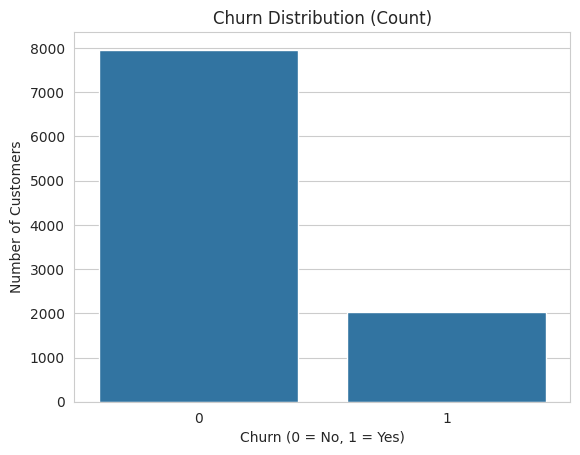

In [11]:
#distribution of churned vs non-churned customers
sns.countplot(x='Exited', data=df)
plt.title('Churn Distribution (Count)')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')
plt.show()

It is seen that majority of the customers have not churned, confirming the class imbalance observed earlier.

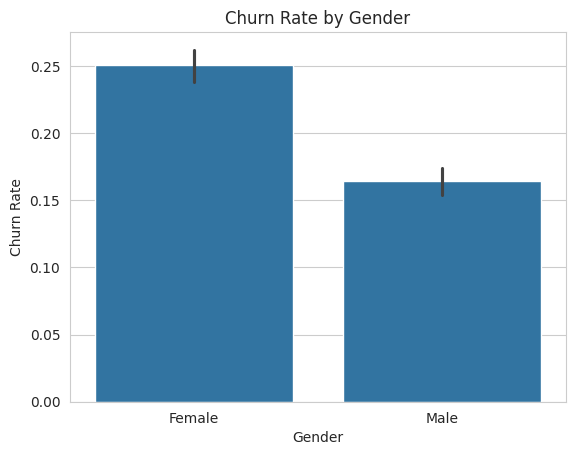

In [12]:
#churn rate by gender
sns.barplot(x='Gender', y='Exited', data=df)
plt.title('Churn Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Churn Rate')
plt.show()

Female customers have a higher churn rate (25%) as compared to their male counterparts (16%), suggesting that gender may affect customer retention.

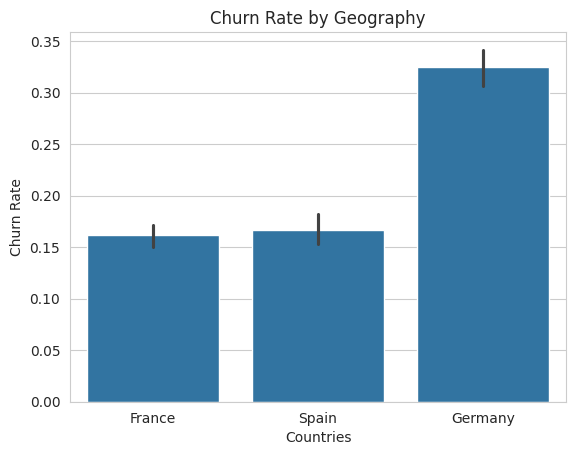

In [13]:
#churn rate by geography
sns.barplot(x='Geography', y='Exited', data=df)
plt.title('Churn Rate by Geography')
plt.xlabel('Countries')
plt.ylabel('Churn Rate')
plt.show()

Germany has a significantly higher churn rate (32%) as compared to France and Spain, showing regional variations in customer behaviour.

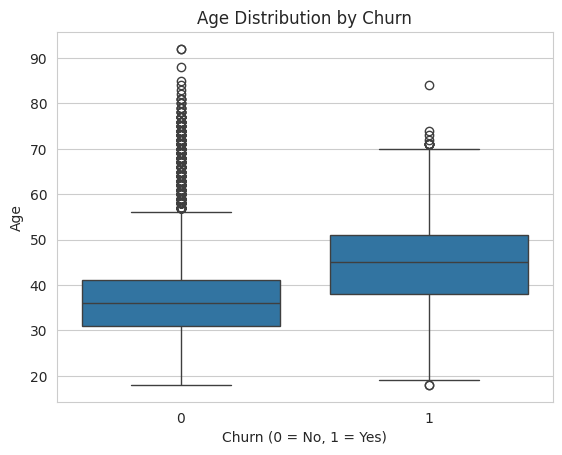

In [14]:
#age distribution by churn
sns.boxplot(x='Exited', y='Age', data=df)
plt.title('Age Distribution by Churn')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.show()

Older customers are more likely to churn, as shown by the higher median age (45yrs).

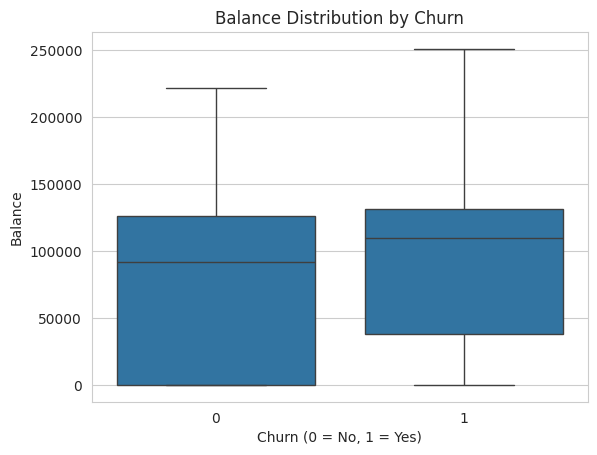

In [15]:
#account balance distribution by churn
sns.boxplot(x='Exited', y='Balance', data=df)
plt.title('Balance Distribution by Churn')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Balance')
plt.show()

Customers with higher account balances churn more than those having lesser account balance. It is also seen that customers with zero or lower account balance are less likely to churn.

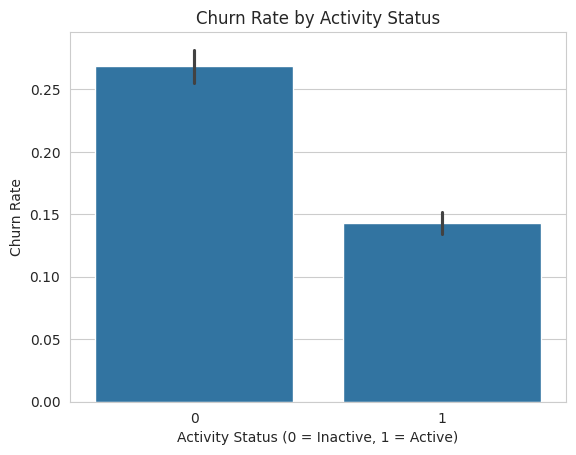

In [16]:
#churn rate by customer activity status
sns.barplot(x='IsActiveMember', y='Exited', data=df)
plt.title('Churn Rate by Activity Status')
plt.xlabel('Activity Status (0 = Inactive, 1 = Active)')
plt.ylabel('Churn Rate')
plt.show()

The churn rate for inactive customers (27%) is significantly higher than that for active customers (14%), showing that customer engagement is important for retaining them.

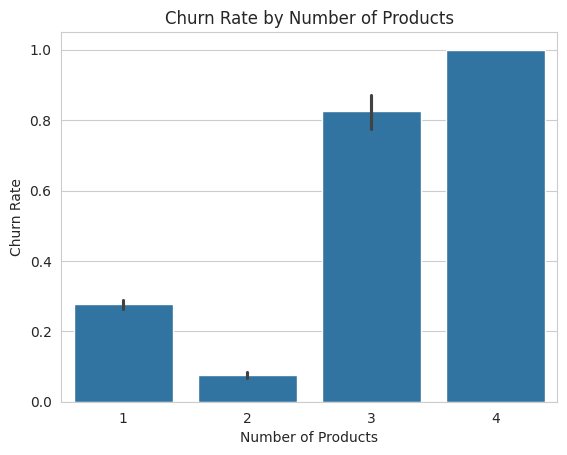

In [17]:
#churn rate by number of products held
sns.barplot(x='NumOfProducts', y='Exited', data=df)
plt.title('Churn Rate by Number of Products')
plt.xlabel('Number of Products')
plt.ylabel('Churn Rate')
plt.show()

In [18]:
df["NumOfProducts"].value_counts()

,count
NumOfProducts,
1,5084
2,4590
3,266
4,60


Customers with 2 products show the lowest churn rate (7.5%), while churn increases for customers with fewer or more products, suggesting a non-linear relationship between number of products used and churn.
Customers with 4 products have a very high churn rate but this may be due to the small number of such customers (60).

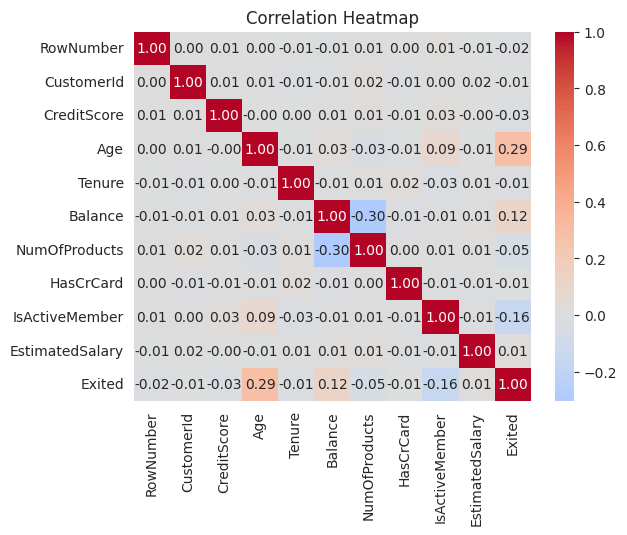

In [19]:
#correlation matrix of numerical features
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f',center =0)
plt.title('Correlation Heatmap')
plt.show()

In [20]:
corr['Exited'].sort_values(ascending=False)

,Exited
Exited,1.000000
Age,0.285323
Balance,0.118533
EstimatedSalary,0.012097
CustomerId,-0.006248
HasCrCard,-0.007138
Tenure,-0.014001
RowNumber,-0.016571
CreditScore,-0.027094
NumOfProducts,-0.047820


Correlation analyis shows that there is a moderate positive correlation (0.285) between age and churn.
A weak negative correlation (-0.156) is seen between activity status and churn, suggesting that inactive customers are more likely to churn.

**SUMMARY OF INSIGHTS :**

Exploratory data analysis has shown that there are multiple factors affecting churn. Inactive customers have a significantly higher churn rate thus indicating that customer engagement is crucial in retaining them. Demographic factors like age, gender, and country also affect churn. Older customers, females, and customers from Germany are most likely to churn.
Customers with high account balance tend to churn more than those with zero to low balance.
A non-linear behaviour pattern is seen, where customers with 2 products churn the least, but those will lesser or more products churn more.